<a href="https://colab.research.google.com/github/kevinnathaneal2006-tech/Deep-learning/blob/main/image_caption_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
!wget "https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip"
!unzip -q flickr8k.zip -d ./flickr8k

--2026-05-03 08:38:37--  https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/753516996/d7c62b13-1e50-40ea-8fae-f34a44b1695f?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-03T09%3A23%3A51Z&rscd=attachment%3B+filename%3Dflickr8k.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-03T08%3A23%3A41Z&ske=2026-05-03T09%3A23%3A51Z&sks=b&skv=2018-11-09&sig=ExN4WcSpmDnu77%2FkF%2FGzaZgoVTt9uBuABfeG8SJ%2BZvI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzgwMTExNywibmJmIjoxNzc3Nzk3NTE3LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

In [3]:
print(os.listdir("flickr8k"))

['Images', 'captions.txt']


In [4]:
print(len(os.listdir("flickr8k/Images")))

8091


In [5]:
files = os.listdir("flickr8k/Images")
print(files[:20])

['3332136681_9aecf101fd.jpg', '384465575_31294122c0.jpg', '3256456935_664a7a5bba.jpg', '3585495069_33cba06d0a.jpg', '2705947033_5999147842.jpg', '2272489996_95b0a62d15.jpg', '241347150_5ff37818c2.jpg', '3549464203_8ab9c6160b.jpg', '3095137758_bdd1e613dd.jpg', '2790909995_8b7a03d9d1.jpg', '3348785391_c243faf6bb.jpg', '2306674172_dc07c7f847.jpg', '1794818900_e0ffdd268e.jpg', '2473293833_78820d2eaa.jpg', '1423997242_ea2189ec5e.jpg', '485357535_b45ba5b6da.jpg', '3534668485_6887629ff0.jpg', '2981702521_2459f2c1c4.jpg', '3296584432_bef3c965a3.jpg', '2616673985_fa4354cc53.jpg']


In [6]:
with open("flickr8k/captions.txt","r") as f:
    lines = f.readlines()
print(len(lines))

40456


In [7]:
model = InceptionV3(weights='imagenet')
model = tf.keras.Model(
    model.input,
    model.layers[-2].output
)

model_encoder = model
print("Encoder Loaded")

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Encoder Loaded


In [8]:
def extract_features(directory):

    features={}

    for img in os.listdir(directory)[:100]:
        path=directory+"/"+img

        image=load_img(path,target_size=(299,299))
        image=img_to_array(image)

        image=np.expand_dims(image,axis=0)
        image=preprocess_input(image)

        feature=model.predict(image,verbose=0)

        features[img]=feature

    return features

features = extract_features("flickr8k/Images")
print("Feature extraction completed")

Feature extraction completed


In [9]:
def load_captions(filename):

    mapping={}

    with open(filename,'r') as file:

        for line in file:
            tokens=line.strip().split(',')

            img_id=tokens[0]
            caption=" ".join(tokens[1:])

            if img_id not in mapping:
                mapping[img_id]=[]

            mapping[img_id].append(
                "startseq " + caption + " endseq"
            )

    return mapping

captions=load_captions(
    "flickr8k/captions.txt"
)

print("Captions Loaded")

Captions Loaded


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

all_captions=[]

for key in captions:
    for cap in captions[key]:
        all_captions.append(cap)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index)+1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 8497


In [11]:
max_length = max(
    len(c.split())
    for c in all_captions
)

print("Max Caption Length:", max_length)

Max Caption Length: 39


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Training data lists
X1 = []
X2 = []
y = []

count = 0

for img, caption_list in captions.items():

    # Skip if image feature not extracted
    if img not in features:
        continue

    for caption in caption_list:

        # Convert caption words to numbers
        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        # Create input-output pairs
        for i in range(1, len(seq)):

            # Input sequence
            in_seq = seq[:i]

            # Next word (target)
            out_seq = seq[i]

            # Pad sequence
            in_seq = pad_sequences(
                [in_seq],
                maxlen=max_length
            )[0]

            # Store training data
            X1.append(features[img][0])
            X2.append(in_seq)

            # Store target as integer
            y.append(out_seq)

    count += 1

    # Use 50 images first to reduce RAM
    if count == 500:
        break


# Convert lists to arrays
X1 = np.array(X1)
X2 = np.array(X2)
y  = np.array(y)

print("Training data ready")
print(X1.shape)
print(X2.shape)
print(y.shape)

Training data ready
(6001, 2048)
(6001, 39)
(6001,)


In [13]:
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add
from tensorflow.keras.models import Model

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256,activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

# FIXED
se1 = Embedding(vocab_size,256)(inputs2)

se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2,se3])
decoder2 = Dense(256,activation='relu')(decoder1)

outputs = Dense(
    vocab_size,
    activation='softmax'
)(decoder2)

model = Model(
    inputs=[inputs1,inputs2],
    outputs=outputs
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 39, 256)   │  2,175,232 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 39, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8497)      │  2,183,729 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,474,609 (20.88 MB)

 Trainable params: 5,474,609 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
model.fit(
    [X1, X2],
    y,
    epochs=25,
    batch_size=32
)

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.6966
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6012
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0198
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.5116
Epoch 5/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.0721
Epoch 6/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.6805
Epoch 7/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3423
Epoch 8/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0656
Epoch 9/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8586
Epoch 10/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.6795
Epoch 11/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5089
Epoch 12/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3377
Epoch 13/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.2226
Epoch 14/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1223
Epoch 15/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s

In [17]:
def generate_caption(model, image_feature):

    caption = "startseq"

    for i in range(max_length):

        seq = tokenizer.texts_to_sequences(
            [caption]
        )[0]

        seq = pad_sequences(
            [seq],
            maxlen=max_length
        )

        yhat = model.predict(
            [image_feature, seq],
            verbose=0
        )

        yhat = np.argmax(yhat)

        word = None

        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break


    # Remove startseq and endseq
    return caption.replace(
        "startseq",""
    ).replace(
        "endseq",""
    ).strip()

In [18]:
test_img = list(features.keys())[65]

print(test_img)

print(
generate_caption(
    model,
    features[test_img]
)
)

2447972568_1e9b287691.jpg
a man with a close cropped haircut is waiting to catch a child that he has thrown into the air


Generated Caption: a man with a close cropped haircut is waiting to catch a child that he has thrown into the air


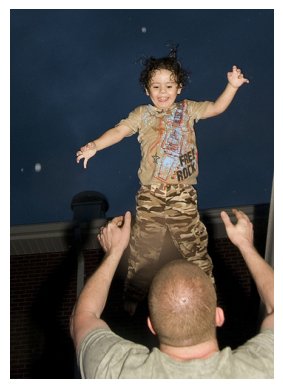

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

test_img = list(features.keys())[65]

img = Image.open(
    "flickr8k/Images/" + test_img
)

plt.imshow(img)
plt.axis("off")

caption = generate_caption(
    model,
    features[test_img]
)

print("Generated Caption:", caption)

In [31]:
from google.colab import files
files.upload()

Saving cycle.jpg to cycle (1).jpg


{'cycle (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xe1\x00\xd3Exif\x00\x00II*\x00\x08\x00\x00\x00\x03\x00\x0e\x01\x02\x00\x89\x00\x00\x002\x00\x00\x00\x1a\x01\x05\x00\x01\x00\x00\x00\xbb\x00\x00\x00\x1b\x01\x05\x00\x01\x00\x00\x00\xc3\x00\x00\x00\x00\x00\x00\x00Smiling young adult black man enjoying sport with friends in nature. Adventure trip in colourful autumn forest, active lifestyle concept.,\x01\x00\x00\x01\x00\x00\x00,\x01\x00\x00\x01\x00\x00\x00\xff\xe1\x05\xd6http://ns.adobe.com/xap/1.0/\x00<?xpacket begin="\xef\xbb\xbf" id="W5M0MpCehiHzreSzNTczkc9d"?>\n<x:xmpmeta xmlns:x="adobe:ns:meta/">\n\t<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n\t\t<rdf:Description rdf:about="" xmlns:photoshop="http://ns.adobe.com/photoshop/1.0/" xmlns:Iptc4xmpCore="http://iptc.org/std/Iptc4xmpCore/1.0/xmlns/"   xmlns:GettyImagesGIFT="http://xmp.gettyimages.com/gift/1.0/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:plus="http://ns.useplus

In [32]:
def extract_feature_single(img_path):

    image = load_img(img_path, target_size=(299,299))
    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    feature = model_encoder.predict(image, verbose=0)

    return feature

Enter image name: cycle.jpg
Generated Caption: two people are riding a bike on a dirt road


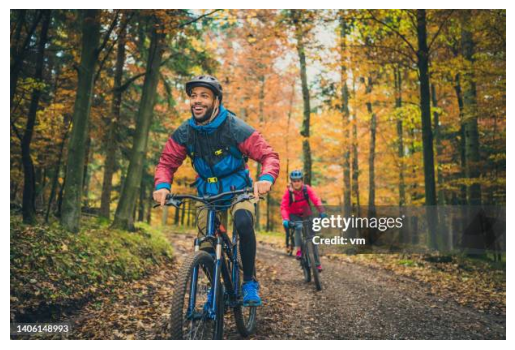

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

img_path = input("Enter image name: ")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

feature = extract_feature_single(img_path)
caption = generate_caption(model, feature)

print("Generated Caption:", caption)